<a href="https://colab.research.google.com/github/burka5032/Obfuscation-Resilient/blob/main/AU_v1_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

'AU-PEMal-2025-V1_Cleaned.csv' not found. Checking for raw dataset...
Please upload 'AU-PEMal-2025-V1.csv':


Saving AU-PEMal-2025-V1.csv to AU-PEMal-2025-V1.csv

--- Cleaning Raw Dataset: 'AU-PEMal-2025-V1.csv' ---
Raw Dataset Shape: 21703 rows, 39 columns
Dropped identifier columns: ['sha1']
Successfully saved 'AU-PEMal-2025-V1_Cleaned.csv' (21572 rows, 36 columns).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- Loading Cleaned Dataset: 'AU-PEMal-2025-V1_Cleaned.csv' ---
Features matrix shape: (21572, 35)
Target distribution: {'Malware': np.int64(10803), 'Benign': np.int64(10769)}

================ EVALUATION METRICS ================
Overall Accuracy: 99.40%

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign     0.9967    0.9912    0.9939      2154
     Malware     0.9913    0.9968    0.9940      2161

    accuracy                         0.9940      4315
   macro avg     0.9940    0.9940    0.9940      4315
weighted avg     0.9940    0.9940    0.9940      4315

================ CONFUSION RATE ANALYSIS ================
Total Test Samples: 4315
Benign Samples: 2154 | Malware Samples: 2161

False Positives (Benign misclassified as Malware): 19 (0.88% confusion rate)
False Negatives (Malware misclassified as Benign): 7 (0.32% confusion rate)
Overall Dataset Misclassification/Confusion Rate: 0.60%



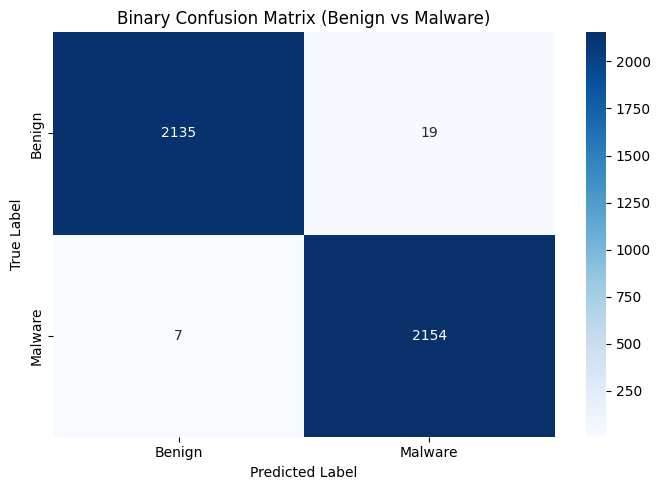

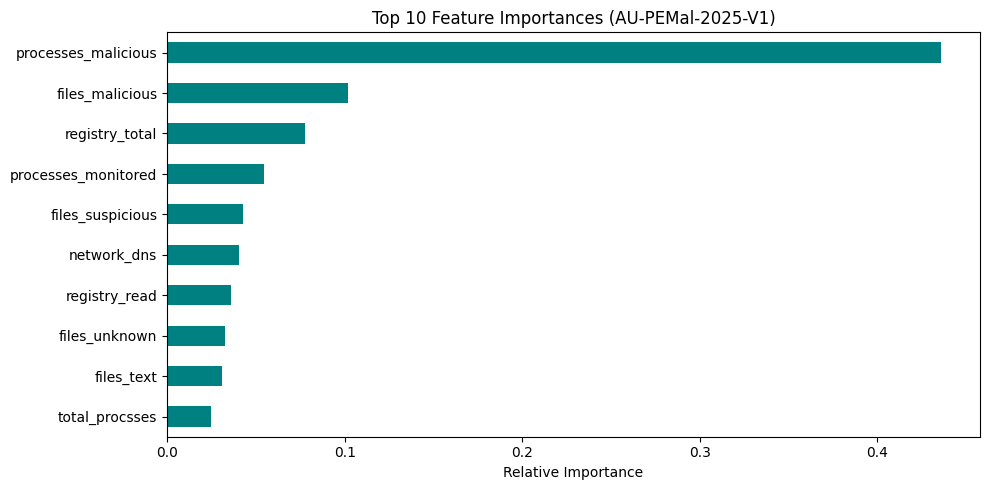

In [1]:
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

input_file = "AU-PEMal-2025-V1.csv"
cleaned_file = "AU-PEMal-2025-V1_Cleaned.csv"

# ---------------------------------------------------------
# 1. Dataset Acquisition & Raw File Resolution
# ---------------------------------------------------------
if not os.path.exists(cleaned_file):
    print(f"'{cleaned_file}' not found. Checking for raw dataset...")
    if not os.path.exists(input_file):
        raw_files = [
            f for f in glob.glob("AU-PEMal-2025-V1*.csv") if "Cleaned" not in f
        ]
        if raw_files:
            input_file = raw_files[0]
            print(f"Found raw file: '{input_file}'")
        else:
            try:
                from google.colab import files

                print(f"Please upload '{input_file}':")
                uploaded = files.upload()
                input_file = list(uploaded.keys())[0]
            except ImportError:
                raise FileNotFoundError(
                    f"Cannot find '{input_file}' in the current working directory."
                )

# ---------------------------------------------------------
# 2. Data Preprocessing & Cleaning Pipeline
# ---------------------------------------------------------
if not os.path.exists(cleaned_file):
    print(f"\n--- Cleaning Raw Dataset: '{input_file}' ---")
    df_raw = pd.read_csv(input_file)
    print(
        f"Raw Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns"
    )

    # A. Drop non-predictive hash / identifier columns
    non_feature_cols = [
        "sha1",
        "Name",
        "filename",
        "Raw_filename",
        "hash",
        "md5",
    ]
    cols_to_drop = [c for c in non_feature_cols if c in df_raw.columns]
    if cols_to_drop:
        df_raw = df_raw.drop(columns=cols_to_drop)
        print(f"Dropped identifier columns: {cols_to_drop}")

    # B. Convert PE Header Hexadecimal strings ('0x...') to numeric integers
    hex_cols = [
        "EntryPoint",
        "SizeOfCode",
        "SizeOfImage",
        "SizeOfInitializedData",
        "SizeOfUninitializedData",
        "rdata_VirtualSize",
        "rdata_VirtualAddress",
        "rdata_SizeOfRawData",
        "rdata_PointerToRawData",
        "text_VirtualSize",
        "text_SizeOfRawData",
        "text_PointerToRawData",
        "BaseOfCode",
        "BaseOfData",
        "ImageBase",
        "Checksum",
        "SectionAlignment",
        "SizeOfHeaders",
    ]

    def parse_hex_to_int(val):
        if pd.isna(val):
            return 0
        val_str = str(val).strip()
        try:
            if val_str.lower().startswith("0x"):
                return int(val_str, 16)
            else:
                return int(float(val_str))
        except Exception:
            return 0

    for col in hex_cols:
        if col in df_raw.columns:
            df_raw[col] = df_raw[col].apply(parse_hex_to_int)

    # C. Normalize Target to Binary ('Benign' vs 'Malware')
    if "Class" in df_raw.columns:
        binary_series = df_raw["Class"].copy()
    elif "Category" in df_raw.columns:
        binary_series = df_raw["Category"].apply(
            lambda x: (
                "Benign" if str(x).strip().lower() == "benign" else "Malware"
            )
        )
    elif "Family" in df_raw.columns:
        binary_series = df_raw["Family"].apply(
            lambda x: (
                "Benign" if str(x).strip().lower() == "benign" else "Malware"
            )
        )
    else:
        raise ValueError("No target column found for binary classification.")

    def standardize_label(val):
        val_str = str(val).strip().lower()
        if val_str in ["0", "benign", "goodware"]:
            return "Benign"
        return "Malware"

    y_binary = binary_series.apply(standardize_label)

    # D. Drop target/sub-category columns and retain numeric features
    all_target_labels = ["Class", "Category", "Family", "label", "target"]
    X_clean = df_raw.drop(
        columns=[c for c in all_target_labels if c in df_raw.columns]
    )
    X_clean = X_clean.select_dtypes(include=[np.number])

    # E. Drop zero-variance constant features
    constant_cols = [c for c in X_clean.columns if X_clean[c].nunique() <= 1]
    if constant_cols:
        X_clean = X_clean.drop(columns=constant_cols)
        print(f"Dropped zero-variance columns: {constant_cols}")

    # F. Drop duplicates and missing values
    df_clean = pd.concat([X_clean, y_binary.rename("Class")], axis=1)
    df_clean = df_clean.dropna().drop_duplicates(keep="first")

    # ---------------------------------------------------------
    # 3. Save Cleaned Dataset to File
    # ---------------------------------------------------------
    df_clean.to_csv(cleaned_file, index=False)
    print(
        f"Successfully saved '{cleaned_file}' ({df_clean.shape[0]} rows, {df_clean.shape[1]} columns)."
    )

    try:
        from google.colab import files

        files.download(cleaned_file)
    except Exception:
        pass

# ---------------------------------------------------------
# 4. Load Cleaned Dataset & Train Random Forest Model
# ---------------------------------------------------------
print(f"\n--- Loading Cleaned Dataset: '{cleaned_file}' ---")
df = pd.read_csv(cleaned_file)

X = df.drop(columns=["Class"]).select_dtypes(include=[np.number])
y_raw = df["Class"]

le = LabelEncoder()
y = le.fit_transform(y_raw)
class_names = [str(c) for c in le.classes_]

print(f"Features matrix shape: {X.shape}")
print(f"Target distribution: {dict(pd.Series(y_raw).value_counts())}")

# Stratified Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Train Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. Performance Metrics & Confusion Rate Analysis
# ---------------------------------------------------------
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\n================ EVALUATION METRICS ================")
print(f"Overall Accuracy: {acc * 100:.2f}%\n")
print("CLASSIFICATION REPORT:")
print(
    classification_report(y_test, y_pred, target_names=class_names, digits=4)
)

# Confusion Matrix Analysis
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

benign_total = tn + fp
malware_total = fn + tp
total_samples = len(y_test)

fpr = (fp / benign_total) * 100 if benign_total > 0 else 0.0  # Benign -> Malware
fnr = (
    (fn / malware_total) * 100 if malware_total > 0 else 0.0
)  # Malware -> Benign
overall_confusion_rate = ((fp + fn) / total_samples) * 100

print("================ CONFUSION RATE ANALYSIS ================")
print(f"Total Test Samples: {total_samples}")
print(f"Benign Samples: {benign_total} | Malware Samples: {malware_total}\n")
print(
    f"False Positives (Benign misclassified as Malware): {fp} ({fpr:.2f}% confusion rate)"
)
print(
    f"False Negatives (Malware misclassified as Benign): {fn} ({fnr:.2f}% confusion rate)"
)
print(
    f"Overall Dataset Misclassification/Confusion Rate: {overall_confusion_rate:.2f}%\n"
)

# ---------------------------------------------------------
# 6. Confusion Matrix Heatmap & Feature Importances
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Binary Confusion Matrix (Benign vs Malware)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("binary_confusion_matrix.png", dpi=300)
plt.show()

# Top 10 Feature Importances
importances = pd.Series(model.feature_importances_, index=X.columns)
top_10 = importances.nlargest(10)

plt.figure(figsize=(10, 5))
top_10.plot(kind="barh", color="teal")
plt.title("Top 10 Feature Importances (AU-PEMal-2025-V1)")
plt.xlabel("Relative Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("binary_feature_importance.png", dpi=300)
plt.show()